In [1]:
pip install tensorflow  


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier


In [3]:
# Step 2: Load Dataset
df = pd.read_csv(r"C:\Users\Admin\Downloads\X73.csv")
print(df.head())


   TopDepth  BotDepth      _CAL      _GR       _SP     _LLD      _LLS  \
0   1067.04   1072.49  10.04000  89.8772  -8.14240  4.27824  2.994030   
1   1072.49   1075.02  10.56070  88.0208  -7.84358  4.06225  0.904588   
2   1075.02   1077.01   9.96903  85.9513  -7.12793  3.91594  1.638560   
3   1077.01   1079.81   9.15199  80.7888  -7.26352  5.27282  1.902910   
4   1079.81   1081.13   8.72312  74.4485 -10.06840  7.10871  6.509230   

        _AC     _DEN      _PEF Lith_Section  
0   99.4474  2.17588  0.235624     mudstone  
1  105.6210  2.13287  0.251977     mudstone  
2  102.0210  2.31305  0.269664     mudstone  
3  102.8160  2.11194  0.288160     mudstone  
4   95.5701  2.37060  0.305930     mudstone  


In [4]:
# Step 3: Features & Target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [5]:
# Step 4: Handle Missing Values
X = X.fillna(X.mean())

In [6]:
# Step 5: Encode Target (VERY IMPORTANT)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [7]:
# Step 6: Scaling (optional but keeping same format)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# Step 7: Train XGBoost Model (FULL DATA)
xgb = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    objective='multi:softprob',   # Correct for multi-class
    eval_metric='mlogloss',
    random_state=42,
    tree_method='hist'   # faster (optional)
)

xgb.fit(X_scaled, y_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [10]:
# Step 8: Prediction
y_pred = xgb.predict(X_scaled)

In [11]:
# Step 9: Accuracy
print("XGBoost Accuracy (Full Data):", accuracy_score(y_encoded, y_pred))

XGBoost Accuracy (Full Data): 1.0


In [12]:
# Step 10: Classification Report
print("\nClassification Report:\n",
      classification_report(y_encoded, y_pred, target_names=le.classes_))


Classification Report:
                  precision    recall  f1-score   support

muddy siltstone       1.00      1.00      1.00       103
       mudstone       1.00      1.00      1.00       459
      oil shale       1.00      1.00      1.00        17
      siltstone       1.00      1.00      1.00       154
 silty mudstone       1.00      1.00      1.00       173

       accuracy                           1.00       906
      macro avg       1.00      1.00      1.00       906
   weighted avg       1.00      1.00      1.00       906



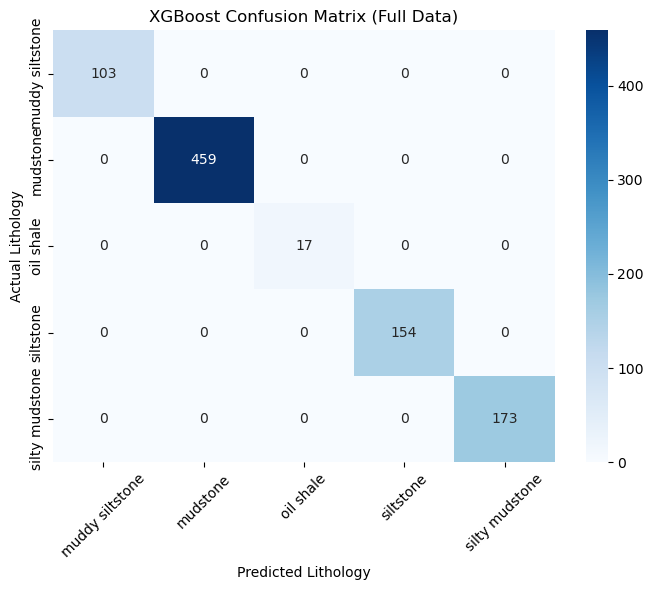

In [13]:
# Step 11: Confusion Matrix
cm = confusion_matrix(y_encoded, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("XGBoost Confusion Matrix (Full Data)")
plt.xlabel("Predicted Lithology")
plt.ylabel("Actual Lithology")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()